In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE


In [4]:
df = pd.read_csv(r"samples.csv")  # عدّل المسار لو احتجت
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0.0
2,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1,0.0
3,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
53539,9,PAYMENT,34561.2,C446193613,0.0,0.0,M1435575219,0.0,0.0,0,0.0
53540,9,PAYMENT,11157.25,C600851685,0.0,0.0,M1783389610,0.0,0.0,0,0.0
53541,9,PAYMENT,14881.2,C854724889,0.0,0.0,M1847730255,0.0,0.0,0,0.0
53542,9,PAYMENT,21560.69,C1341437442,0.0,0.0,M1205670747,0.0,0.0,0,0.0


In [5]:
df.dropna(inplace=True)
df = df.drop_duplicates()

print("Total samples after cleaning:", len(df))
print(df['isFraud'].value_counts())
print(df['isFraud'].value_counts(normalize=True) * 100)

Total samples after cleaning: 53516
isFraud
0    53416
1      100
Name: count, dtype: int64
isFraud
0    99.81314
1     0.18686
Name: proportion, dtype: float64


In [6]:
df_encoded = pd.get_dummies(df, columns=['type'], drop_first=True, dtype='uint8')
df_cleaned = df_encoded.drop(columns=['step', 'nameOrig', 'nameDest', 'isFlaggedFraud'])
data = df_cleaned.reset_index(drop=True)

# تحويل amount لأرقام هنا مرة واحدة للجميع
data['amount'] = pd.to_numeric(data['amount'], errors='coerce').fillna(0)

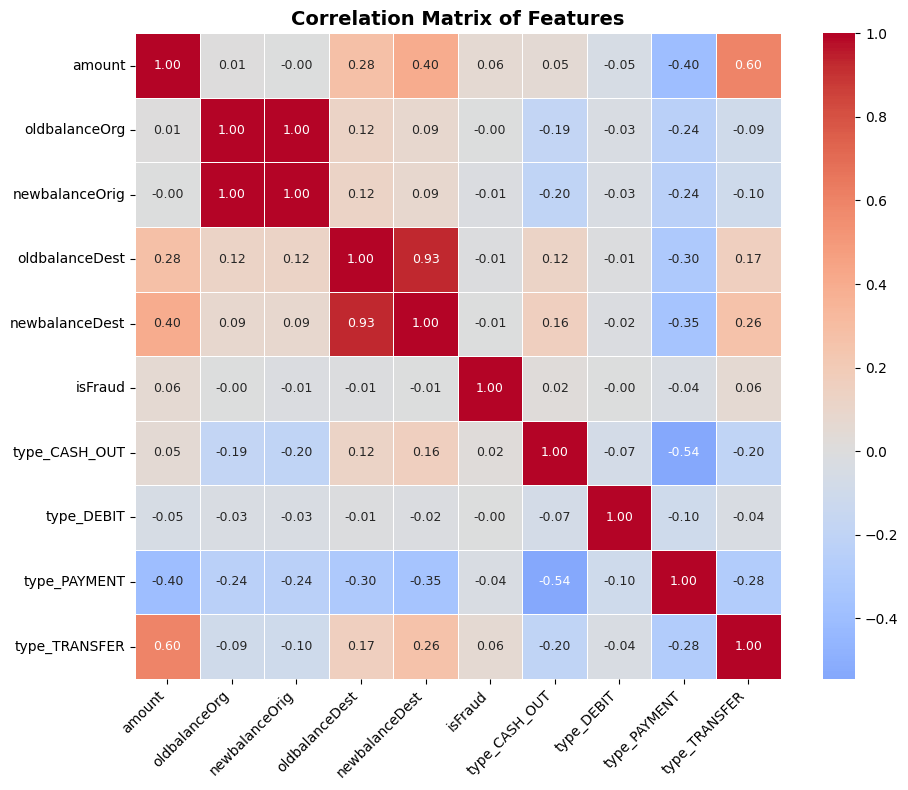

In [26]:
plt.figure(figsize=(10, 8))

# حساب الكورليشن
corr_matrix = data.corr()

# رسم الـ Heatmap
sns.heatmap(
    corr_matrix,
    annot=True,          # إظهار الأرقام
    fmt='.2f',           # رقمين بعد العلامة
    cmap='coolwarm',     # أحمر = علاقة قوية، أزرق = علاقة عكسية
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 9}
)

plt.title('Correlation Matrix of Features', 
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('plot_correlation_matrix.png', dpi=150)
plt.show()

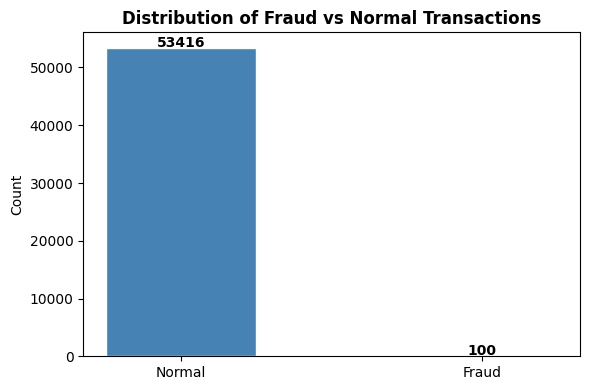

In [36]:
plt.figure(figsize=(6, 4))

counts = df['isFraud'].value_counts().sort_index()

plt.bar(['Normal', 'Fraud'], counts.values, 
        color=['steelblue', 'orangered'], 
        edgecolor='white', width=0.5)

# إضافة الأرقام فوق كل bar
for i, v in enumerate(counts.values):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.title('Distribution of Fraud vs Normal Transactions', fontweight='bold')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plot_fraud_distribution.png', dpi=150)
plt.show()

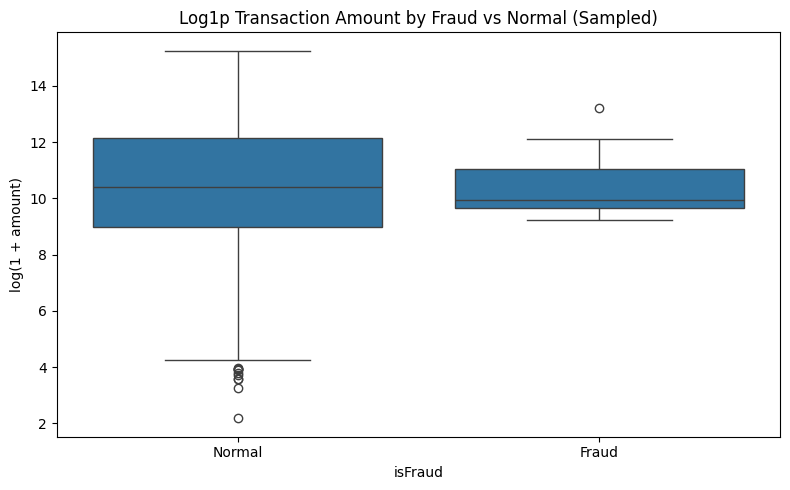

In [8]:
# b) Boxplot للـ Amount (Log Scale) - عينة صغيرة لتجنب التعليق
df_sample = df.copy()
df_sample['amount'] = pd.to_numeric(df_sample['amount'], errors='coerce').fillna(0)
df_sample = df_sample.sample(n=5000, random_state=42)
df_sample['amount_log'] = np.log1p(df_sample['amount'])

plt.figure(figsize=(8, 5))
sns.boxplot(x='isFraud', y='amount_log', data=df_sample)
plt.title('Log1p Transaction Amount by Fraud vs Normal (Sampled)')
plt.xticks([0, 1], ['Normal', 'Fraud'])
plt.ylabel('log(1 + amount)')
plt.tight_layout()
plt.savefig('plot_amount_boxplot.png', dpi=150)
plt.show()

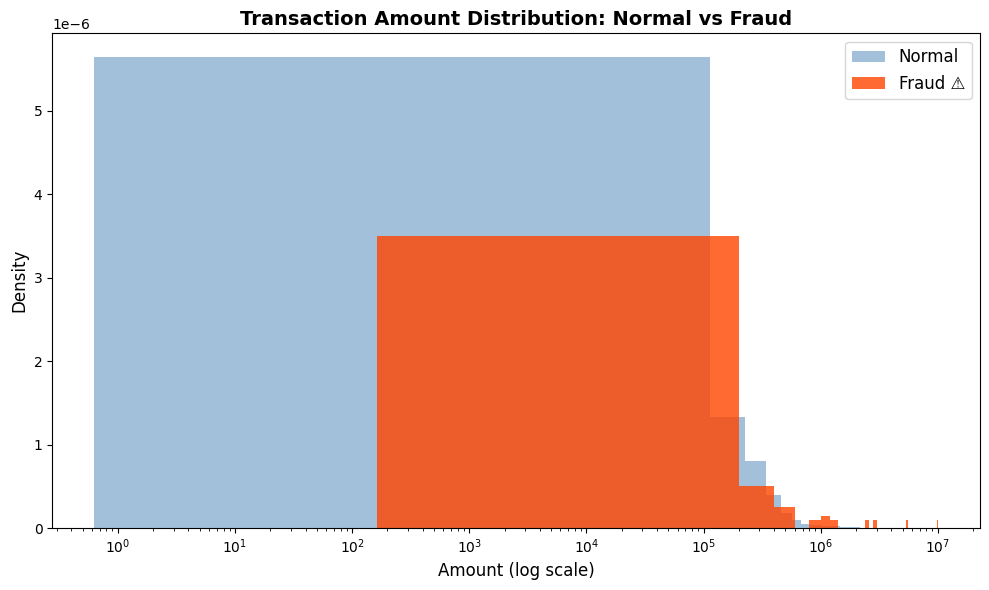

In [25]:
df_hist = df.copy()
df_hist['amount'] = pd.to_numeric(df_hist['amount'], errors='coerce').fillna(0)
df_hist = df_hist[df_hist['amount'] > 0]  # إزالة الأصفار

plt.figure(figsize=(10, 6))

normal_data = df_hist[df_hist['isFraud'] == 0]['amount']
fraud_data  = df_hist[df_hist['isFraud'] == 1]['amount']

plt.hist(normal_data, bins=50, color='steelblue', alpha=0.5, 
         label='Normal', density=True, log=False)
plt.hist(fraud_data,  bins=50, color='orangered', alpha=0.8, 
         label='Fraud ⚠️', density=True, log=False)

plt.xscale('log')
plt.xlabel('Amount (log scale)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Transaction Amount Distribution: Normal vs Fraud', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plot_amount_histogram.png', dpi=150)
plt.show()

In [10]:
X = data.drop('isFraud', axis=1)
y = data['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [11]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nBefore SMOTE:\n", y_train.value_counts())
print("After SMOTE:\n", y_train_res.value_counts())


Before SMOTE:
 isFraud
0    37391
1       70
Name: count, dtype: int64
After SMOTE:
 isFraud
0    37391
1    37391
Name: count, dtype: int64


In [12]:
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [13]:
# ----- Logistic Regression -----
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_res, y_train_res)
y_pred_lr = lr_model.predict(X_test)

print("\n📊 Logistic Regression:")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


📊 Logistic Regression:
[[14761  1264]
 [    2    28]]
              precision    recall  f1-score   support

           0       1.00      0.92      0.96     16025
           1       0.02      0.93      0.04        30

    accuracy                           0.92     16055
   macro avg       0.51      0.93      0.50     16055
weighted avg       1.00      0.92      0.96     16055



In [14]:
# ----- Random Forest -----
rf_model = RandomForestClassifier(
    max_depth=20, min_samples_split=2, n_estimators=100,
    random_state=42, class_weight='balanced'
)
rf_model.fit(X_train_res, y_train_res)
y_pred_rf = rf_model.predict(X_test)

print("\n📊 Random Forest:")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


📊 Random Forest:
[[15997    28]
 [   10    20]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16025
           1       0.42      0.67      0.51        30

    accuracy                           1.00     16055
   macro avg       0.71      0.83      0.76     16055
weighted avg       1.00      1.00      1.00     16055



In [15]:
# ----- SVM -----
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_res_scaled, y_train_res)
y_pred_svm = svm_model.predict(X_test_scaled)

print("\n📊 SVM:")
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


📊 SVM:
[[14841  1184]
 [    4    26]]
              precision    recall  f1-score   support

           0       1.00      0.93      0.96     16025
           1       0.02      0.87      0.04        30

    accuracy                           0.93     16055
   macro avg       0.51      0.90      0.50     16055
weighted avg       1.00      0.93      0.96     16055



In [16]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, scoring='f1', cv=3, n_jobs=-1, verbose=2
)
grid_search.fit(X_train_res, y_train_res)

print("\n✅ Best RF params:", grid_search.best_params_)
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print("\n📊 Random Forest (GridSearch):")
print(classification_report(y_test, y_pred_best_rf))

Fitting 3 folds for each of 27 candidates, totalling 81 fits

✅ Best RF params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

📊 Random Forest (GridSearch):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16025
           1       0.40      0.63      0.49        30

    accuracy                           1.00     16055
   macro avg       0.70      0.82      0.75     16055
weighted avg       1.00      1.00      1.00     16055



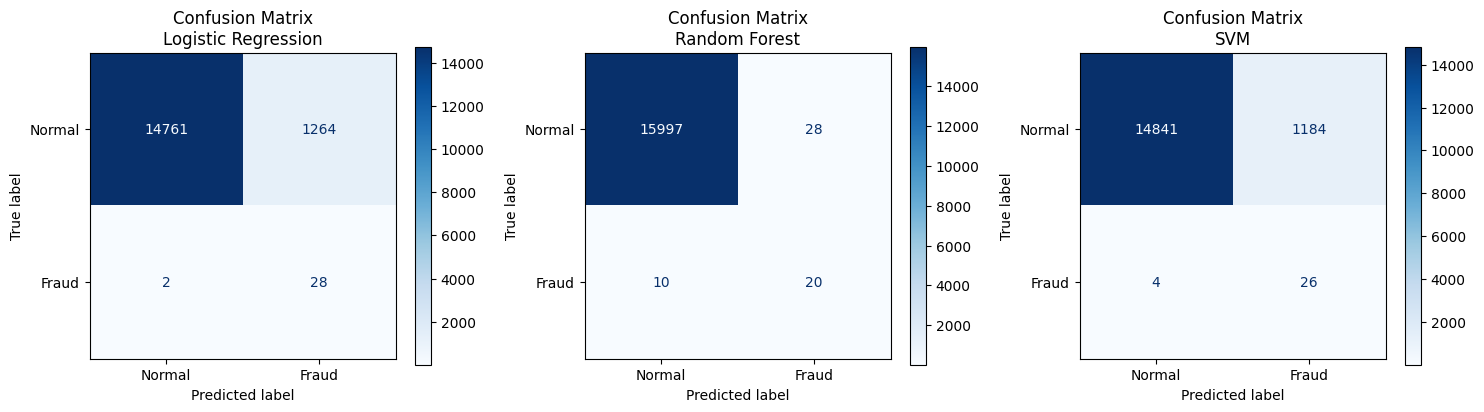

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (model_name, y_pred) in zip(axes, [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest", y_pred_rf),
    ("SVM", y_pred_svm)
]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Normal', 'Fraud'],
        cmap='Blues', ax=ax
    )
    ax.set_title(f'Confusion Matrix\n{model_name}')

plt.tight_layout()
plt.savefig('plot_confusion_matrices.png', dpi=150)
plt.show()

In [ ]:
#joblib.dump(best_rf, 'fraud_rf_model.pkl')
#joblib.dump(scaler, 'scaler.pkl')
print("\n💾 Model saved as 'fraud_rf_model.pkl'")
print("💾 Scaler saved as 'scaler.pkl'")


💾 Model saved as 'fraud_rf_model.pkl'
💾 Scaler saved as 'scaler.pkl'


In [30]:
loaded_model = joblib.load('fraud_rf_model.pkl')

new_transaction_normal = {
    'amount': 5000,
    'oldbalanceOrg': 20000,
    'newbalanceOrig': 15000,
    'oldbalanceDest': 1000,
    'newbalanceDest': 6000,
    'type_CASH_OUT': 0,
    'type_DEBIT': 0,
    'type_PAYMENT': 1,
    'type_TRANSFER': 0
}

new_transaction_fraud = {
    'amount': 181,
    'oldbalanceOrg': 181,
    'newbalanceOrig': 0,
    'oldbalanceDest': 0,
    'newbalanceDest': 0,
    'type_CASH_OUT': 0,
    'type_DEBIT': 0,
    'type_PAYMENT': 0,
    'type_TRANSFER': 1
}

df_new = pd.DataFrame([new_transaction_normal, new_transaction_fraud])
predictions = loaded_model.predict(df_new)

df_new['Prediction'] = ['Normal ✅' if p == 0 else 'Fraud ⚠️' for p in predictions]
df_new.index = ['Transaction 1', 'Transaction 2']

# إظهار الأعمدة المهمة بس
print("\n\n\n\n\n\n\n\n\n\n🔍 Prediction Results:")
print("=" * 65)
print(df_new[['amount', 'oldbalanceOrg', 'newbalanceOrig', 
              'oldbalanceDest', 'newbalanceDest', 'Prediction']].to_string())
print("=" * 65)












🔍 Prediction Results:
               amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  newbalanceDest Prediction
Transaction 1    5000          20000           15000            1000            6000   Normal ✅
Transaction 2     181            181               0               0               0   Fraud ⚠️
